### Understanding the Top Hat Transform
The **Top Hat** (or White Top Hat) morphological operation is used to extract small elements and details from an image. It's calculated as the difference between the original image and its morphological opening.

Mathematically, Top Hat = `Original Image - Opening(Original Image)`.

*   **Opening** is an erosion followed by a dilation. It tends to remove small objects, thin lines, and noise.

By subtracting the opened image from the original, the Top Hat transform highlights regions that are brighter than their surroundings and smaller than the structuring element. This makes it useful for correcting non-uniform illumination and revealing small, bright features on a darker background.

Original Image (loaded and converted to grayscale):


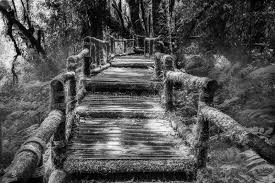

In [1]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Load the specified image
image_path = '/content/images.nikki.jpg'
original_image = cv2.imread(image_path)

if original_image is None:
    print(f"Error: Could not load image from {image_path}")
else:
    # Convert image to grayscale, as morphological operations usually work best on single-channel images
    image = cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY)

    print("Original Image (loaded and converted to grayscale):")
    cv2_imshow(image)


Next, we will define a structuring element (also known as a kernel). The size and shape of this kernel are crucial as they determine the size of the features that the Top Hat operation will detect. We'll use a rectangular kernel in this example.

In [2]:
# Define a structuring element (kernel)
# A common choice is a rectangular kernel.
# The size (e.g., 5x5) determines the scale of features to be extracted.
kernel_size = (9, 9)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, kernel_size)

print(f"Using a {kernel_size[0]}x{kernel_size[1]} rectangular kernel:")
print(kernel)

Using a 9x9 rectangular kernel:
[[1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1]]


Now, we apply the Top Hat morphological operation using `cv2.morphologyEx`.

Top Hat Result:


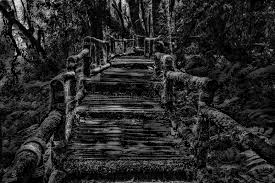

Original Image:


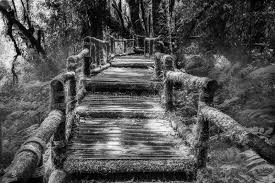

In [3]:
# Apply the Top Hat operation
if 'image' in locals() and image is not None:
    tophat_image = cv2.morphologyEx(image, cv2.MORPH_TOPHAT, kernel)

    print("Top Hat Result:")
    cv2_imshow(tophat_image)

    # You can also display the original image again for comparison
    print("Original Image:")
    cv2_imshow(image)
else:
    print("Image not loaded. Please ensure the image path is correct in the previous cell.")